# Load data for 10 random stocks for few years before 2021, with price between 80 - 600 INR
# data path: "D:\\0dot1_Aug_2016_master\\data\\mstock_mtf_daily_data",
# A system, where we can define a seed number, and for each seed, same stock loads the data and make line plot for all the stocks, one stock per row.

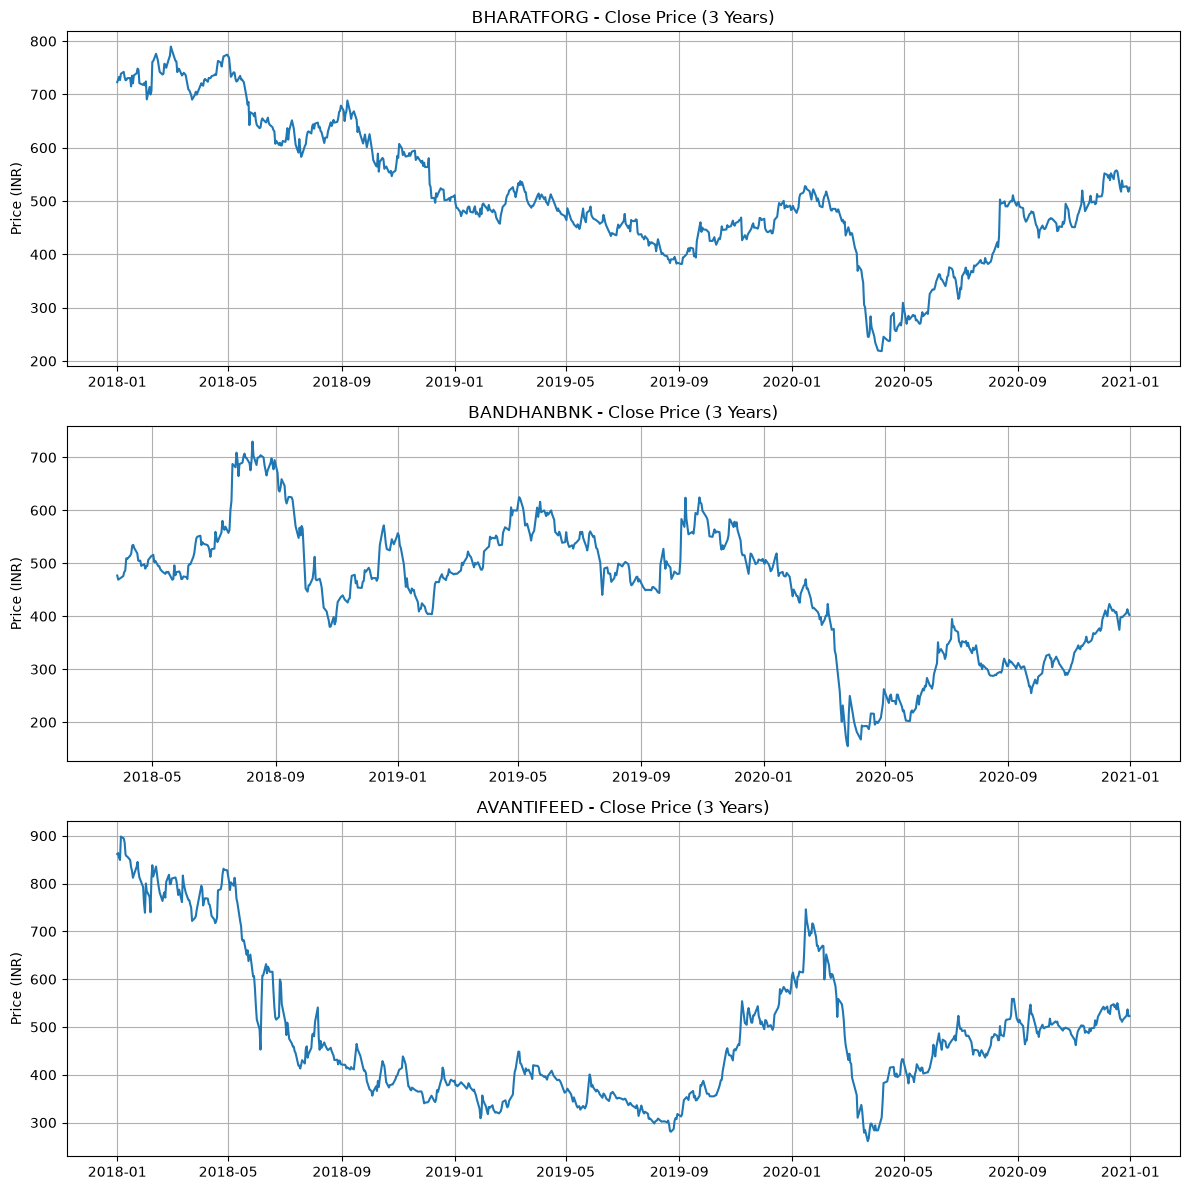

In [1]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt

# Define configurable parameters
MAX_STOCKS = 3
MAX_PERIOD_YEARS = 3  # Maximum number of years of data to load
MAX_ZERO_VOLUME_PCT = 0.05  # Max allowed percentage of 0 volume days

data_dir = r"D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data"
all_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

valid_stocks = []
for file in all_files:
    try:
        df = pd.read_csv(os.path.join(data_dir, file))
        df['Date'] = pd.to_datetime(df['Date'])
        
        # Filter data for max_period_years before 2021
        end_year = 2021
        start_year = end_year - MAX_PERIOD_YEARS
        df = df[(df['Date'].dt.year >= start_year) & (df['Date'].dt.year < end_year)].copy()
        
        if len(df) < 100:  # Ensure we have enough data
            continue
            
        # Filter out stocks with too many 0 volume days (e.g. trading suspensions)
        zero_vol_pct = (df['Volume'] == 0).sum() / len(df)
        if zero_vol_pct > MAX_ZERO_VOLUME_PCT:
            continue
        
        mean_price = df['Close'].mean()
        if 80 <= mean_price <= 600:
            valid_stocks.append((file.replace('.csv', ''), df))
            
        if len(valid_stocks) >= 50:
            break
    except Exception as e:
        continue

selected_stocks = random.sample(valid_stocks, min(MAX_STOCKS, len(valid_stocks)))

fig, axes = plt.subplots(len(selected_stocks), 1, figsize=(12, 4 * len(selected_stocks)))
if len(selected_stocks) == 1:
    axes = [axes]

for i, (symbol, df) in enumerate(selected_stocks):
    axes[i].plot(df['Date'], df['Close'], label='Close')
    axes[i].set_title(f'{symbol} - Close Price ({MAX_PERIOD_YEARS} Years)')
    axes[i].set_ylabel('Price (INR)')
    axes[i].grid(True)

plt.tight_layout()
plt.show()


findfont: Failed to find font weight medium, now using 400.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


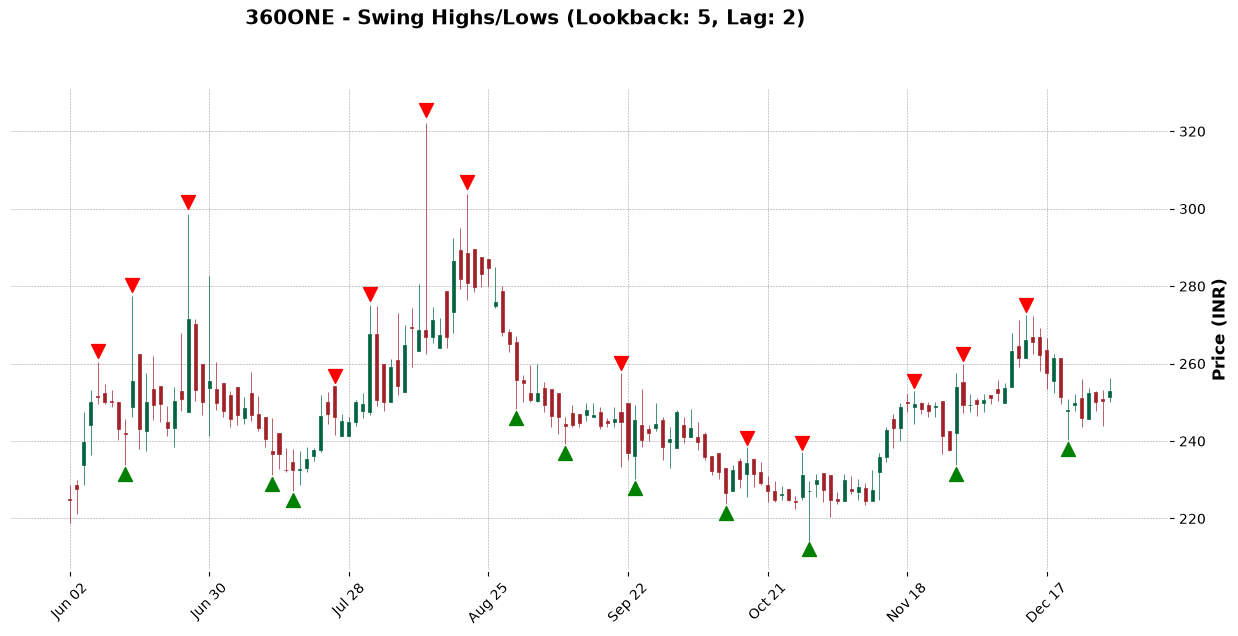

In [2]:
# --- SAMPLE: Swing Highs and Lows (Confirmed Pivot Method) ---
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

LOOKBACK = 5
LAG = 2

# We'll use one of the stocks already loaded, let's just pick the first one from valid_stocks
if len(valid_stocks) > 0:
    sample_symbol, sample_df = valid_stocks[0]
    
    # Make a copy to avoid SettingWithCopy warnings
    df_swing = sample_df.copy()
    
    # Calculate Rolling Max and Min for the LOOKBACK period (excluding the LAG period)
    # We shift by LAG+1 so the window ends right before the candle we are testing
    rolling_max_before = df_swing['High'].shift(LAG + 1).rolling(window=LOOKBACK).max()
    rolling_min_before = df_swing['Low'].shift(LAG + 1).rolling(window=LOOKBACK).min()
    
    # Value at T-LAG
    high_t_lag = df_swing['High'].shift(LAG)
    low_t_lag = df_swing['Low'].shift(LAG)
    
    # Max/Min in the LAG period
    max_after = df_swing['High'].rolling(window=LAG).max()
    min_after = df_swing['Low'].rolling(window=LAG).min()
    
    df_swing['is_swing_high'] = (high_t_lag > rolling_max_before) & (high_t_lag > max_after)
    df_swing['is_swing_low'] = (low_t_lag < rolling_min_before) & (low_t_lag < min_after)
    
    # Shift the boolean flag back to the actual date for plotting
    df_swing['swing_high_plot'] = df_swing['is_swing_high'].shift(-LAG)
    df_swing['swing_low_plot'] = df_swing['is_swing_low'].shift(-LAG)
    
    # For mplfinance, the index must be a DatetimeIndex
    df_swing.set_index('Date', inplace=True)
    
    # Plot only the last 150 days
    plot_df = df_swing.tail(150)
    
    # Prepare the markers for swing highs and lows
    # mplfinance requires the marker array to be the same length as the dataframe. 
    # We use np.nan where there is no marker.
    # Also we add/subtract a tiny amount so the markers sit slightly above/below the wick.
    swing_high_markers = np.where(plot_df['swing_high_plot'] == True, plot_df['High'] * 1.01, np.nan)
    swing_low_markers = np.where(plot_df['swing_low_plot'] == True, plot_df['Low'] * 0.99, np.nan)
    
    # Create addplots for the markers
    apds = []
    # Only add if there are actual non-nan values to prevent errors
    if not np.isnan(swing_high_markers).all():
        apds.append(mpf.make_addplot(swing_high_markers, type='scatter', markersize=100, marker='v', color='red'))
    if not np.isnan(swing_low_markers).all():
        apds.append(mpf.make_addplot(swing_low_markers, type='scatter', markersize=100, marker='^', color='green'))
    
    # Plot Candlestick Chart
    mpf.plot(plot_df,
             type='candle',
             style='charles',
             addplot=apds,
             title=f'{sample_symbol} - Swing Highs/Lows (Lookback: {LOOKBACK}, Lag: {LAG})',
             ylabel='Price (INR)',
             figratio=(14,6),
             figscale=1.2)
else:
    print('No valid stocks found.')


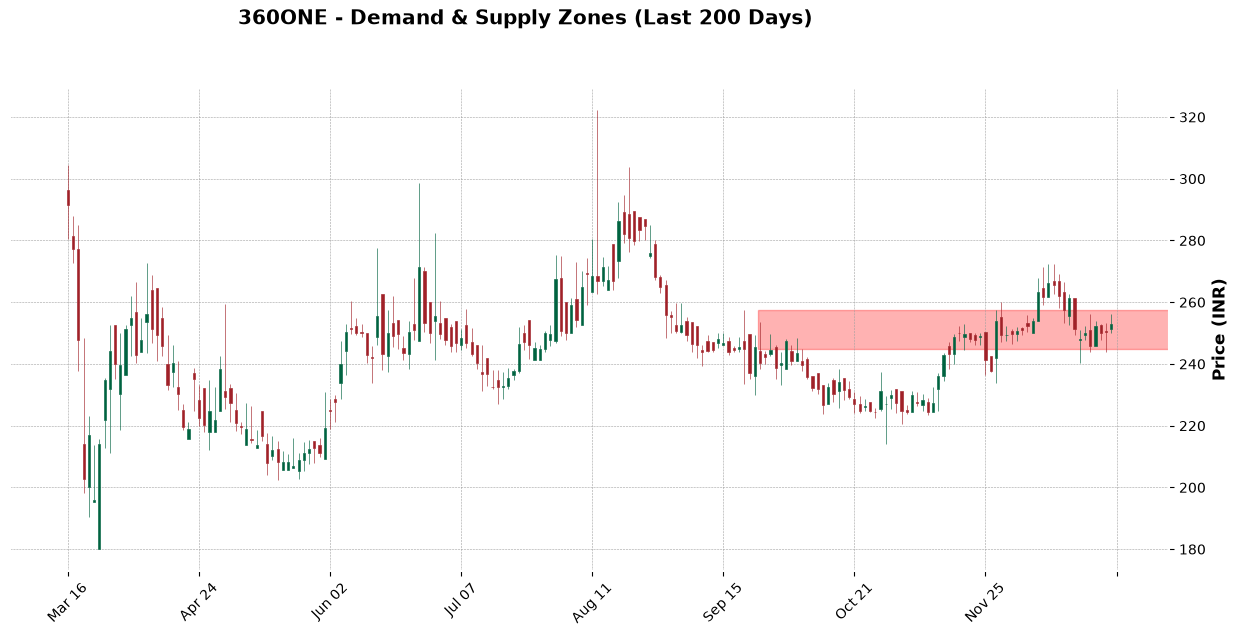

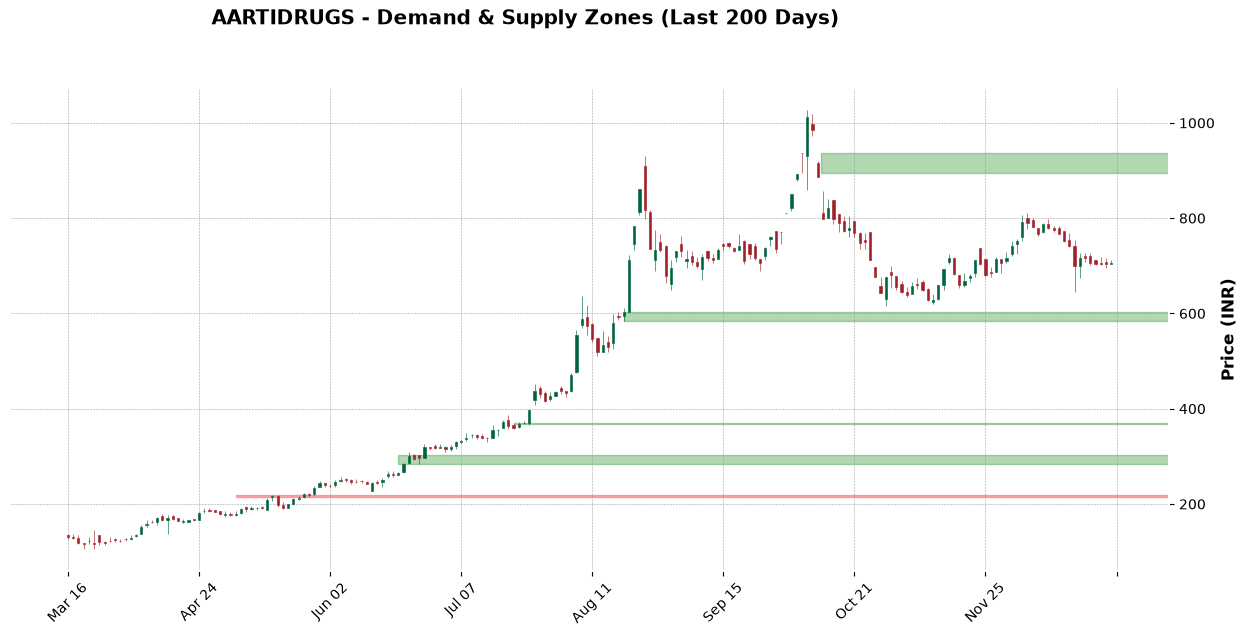

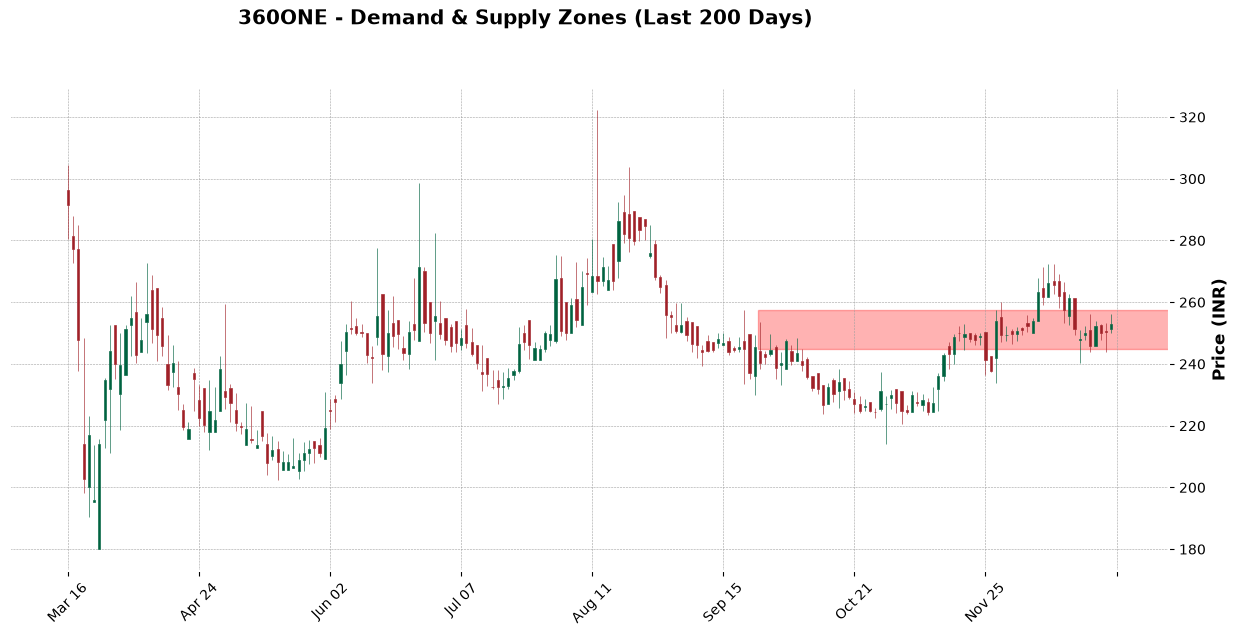

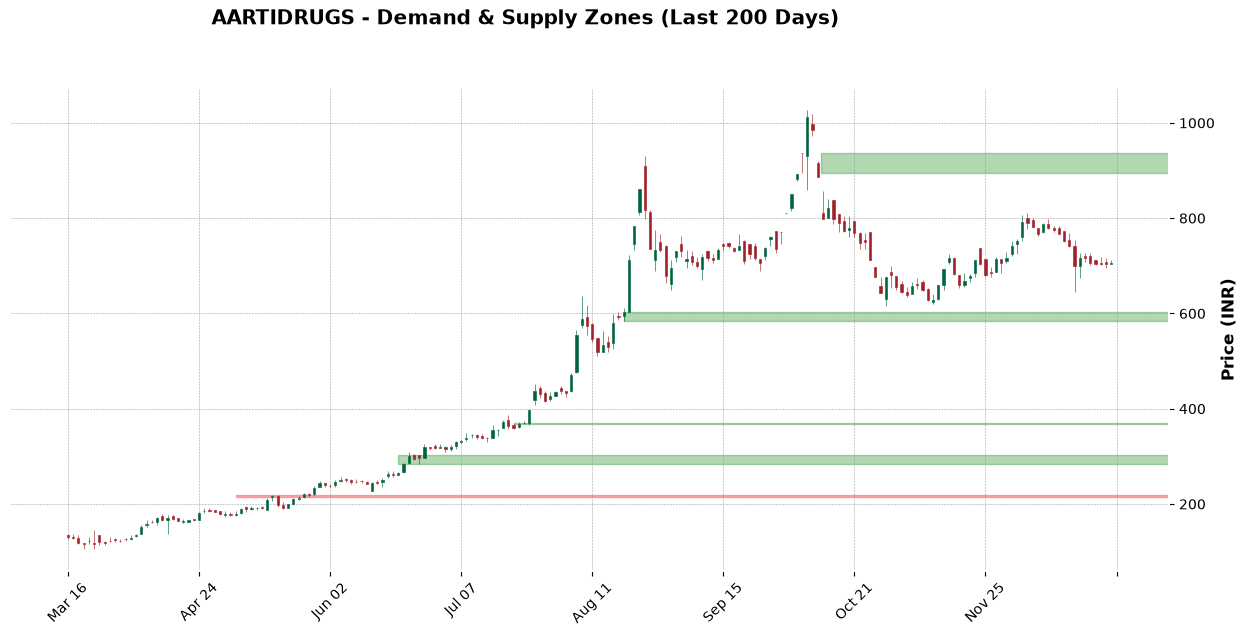

In [3]:
# --- SAMPLE: Demand and Supply Zones ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
from IPython.display import display

# We'll use the first 2 valid stocks for this sample
sample_stocks = valid_stocks[:2]
if len(sample_stocks) == 0:
    print('No valid stocks found.')
else:
    for symbol, sample_df in sample_stocks:
        df = sample_df.copy()
        
        # 1. Calculate ATR (simple 14-period)
        df['TR'] = np.maximum(df['High'] - df['Low'], 
                              np.maximum(abs(df['High'] - df['Close'].shift()), 
                                         abs(df['Low'] - df['Close'].shift())))
        df['ATR'] = df['TR'].rolling(14).mean()
        
        # 2. Identify ERCs and Bases
        df['Body'] = abs(df['Close'] - df['Open'])
        df['Range'] = df['High'] - df['Low']
        
        # Bullish ERC: Close > Open, Body > 1.5 * ATR, Close is in top 25% of candle
        df['is_Bullish_ERC'] = (df['Close'] > df['Open']) & (df['Body'] > df['ATR'] * 1.5) & ((df['High'] - df['Close']) < df['Range'] * 0.25)
        
        # Bearish ERC: Close < Open, Body > 1.5 * ATR, Close is in bottom 25% of candle
        df['is_Bearish_ERC'] = (df['Close'] < df['Open']) & (df['Body'] > df['ATR'] * 1.5) & ((df['Close'] - df['Low']) < df['Range'] * 0.25)
        
        # Base: Body is less than 50% of the Range
        df['is_Base'] = df['Body'] < (df['Range'] * 0.5)
        
        # 3. Find Patterns (1 Base followed by 1 ERC)
        df['is_Demand_Origin'] = df['is_Base'].shift(1) & df['is_Bullish_ERC']
        df['is_Supply_Origin'] = df['is_Base'].shift(1) & df['is_Bearish_ERC']
        
        df.set_index('Date', inplace=True)
        
        # Filter for last 200 days for clear plotting
        plot_df = df.tail(200).copy()
        
        # Collect zones for plotting
        demand_zones = []
        supply_zones = []
        
        for i in range(1, len(plot_df)):
            if plot_df['is_Demand_Origin'].iloc[i]:
                # The base is at i-1
                proximal = max(plot_df['Open'].iloc[i-1], plot_df['Close'].iloc[i-1])
                distal = plot_df['Low'].iloc[i-1]
                demand_zones.append((plot_df.index[i-1], proximal, distal))
                
            if plot_df['is_Supply_Origin'].iloc[i]:
                # The base is at i-1
                proximal = min(plot_df['Open'].iloc[i-1], plot_df['Close'].iloc[i-1])
                distal = plot_df['High'].iloc[i-1]
                supply_zones.append((plot_df.index[i-1], proximal, distal))
                
        # Plot using mplfinance, return figure and axes to draw zones manually
        fig, axes = mpf.plot(plot_df, type='candle', style='charles', returnfig=True,
                             title=f'{symbol} - Demand & Supply Zones (Last 200 Days)',
                             ylabel='Price (INR)', figratio=(14,6), figscale=1.2)
        
        ax = axes[0]
        
        # Draw Demand Zones (Green)
        for start_date, proximal, distal in demand_zones:
            idx = plot_df.index.get_loc(start_date)
            ax.axhspan(distal, proximal, xmin=idx/len(plot_df), xmax=1, color='green', alpha=0.3, zorder=0)
            
        # Draw Supply Zones (Red)
        for start_date, proximal, distal in supply_zones:
            idx = plot_df.index.get_loc(start_date)
            ax.axhspan(distal, proximal, xmin=idx/len(plot_df), xmax=1, color='red', alpha=0.3, zorder=0)
            
        display(fig)
